# Model Evaluation on Teacher Datasets

This notebook loads pre-trained models and evaluates them on the teacher datasets:
1. Load pre-trained models from '../../trained_models/tensorflow/'
2. Load teacher datasets from '../../datasets/'
3. Preprocess the text data for each model
4. Make predictions with each model
5. Compare predictions with actual labels
6. Calculate and visualize accuracy metrics


In [3]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.preprocessing.text import Tokenizer
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
import os
import re
import pickle
import glob
import string
import nltk
from nltk.tokenize import word_tokenize
from nltk.corpus import stopwords

nltk.download('punkt', quiet=True)
nltk.download('stopwords', quiet=True)

np.random.seed(2025)
tf.random.set_seed(2025)


2025-03-27 18:39:09.485620: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2025-03-27 18:39:09.497577: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:477] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1743100749.513714  140024 cuda_dnn.cc:8310] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1743100749.518542  140024 cuda_blas.cc:1418] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
2025-03-27 18:39:09.535999: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instr

## Define Preprocessing Functions

In [4]:
def clean_text(text):
    if not isinstance(text, str):
        return ""
    
    text = text.lower()
    
    text = re.sub(r"https?://\S+|www\.\S+|\S+@\S+\.\S+", "", text)
    
    text = re.sub(r"\s+", " ", text).strip()
    
    return text

def extract_features(texts):
    print("Extracting features...")
    features = []
    stop_words = set(stopwords.words("english"))
    
    for text in texts:
        if not isinstance(text, str) or not text.strip():
            features.append([0] * 8)
            continue
            
        words = word_tokenize(text)
        
        if not words:
            features.append([0] * 8)
            continue
            
        num_words = len(words)
        num_chars = len(text)
        avg_word_length = np.mean([len(w) for w in words]) if words else 0
        num_stopwords = sum(1 for word in words if word.lower() in stop_words)
        stopword_ratio = num_stopwords / num_words if num_words else 0
        
        num_punctuation = sum(1 for char in text if char in string.punctuation)
        punctuation_ratio = num_punctuation / num_chars if num_chars else 0
        
        lexical_diversity = len(set(words)) / num_words if num_words else 0
        
        feature_vector = [
            num_words,
            num_chars,
            avg_word_length,
            num_stopwords,
            stopword_ratio,
            num_punctuation,
            punctuation_ratio,
            lexical_diversity
        ]
        
        features.append(feature_vector)
        
    return np.array(features)


## Load Datasets

In [5]:

teacher_inputs_path = "../datasets/clean/teacher_inputs.csv"
teacher_inputs = pd.read_csv(teacher_inputs_path, sep="\t")
print(f"Teacher inputs shape: {teacher_inputs.shape}")
print(teacher_inputs.head())

teacher_outputs_path = "../datasets/clean/teacher_outputs.csv"
teacher_outputs = pd.read_csv(teacher_outputs_path, sep="\t")
print(f"\nTeacher outputs shape: {teacher_outputs.shape}")
print(teacher_outputs.head())

teacher_data = pd.merge(teacher_inputs, teacher_outputs, on="ID")
print(f"\nMerged data shape: {teacher_data.shape}")
print(teacher_data.head())

teacher_data['numeric_label'] = teacher_data['Label'].apply(lambda x: 0 if x == 'Human' else 1)

print(f"\nLabel distribution: {teacher_data['Label'].value_counts().to_dict()}")


Teacher inputs shape: (80, 2)
     ID                                               Text
0  D1-1  The cell cycle, or cell-division cycle, is the...
1  D1-2  The cell cycle is the process by which a cell ...
2  D1-3  Photons, in many atomic models in physics, are...
3  D1-4  A photon is a fundamental particle of light an...
4  D1-5  According to the theory of plate tectonics, Ea...

Teacher outputs shape: (80, 2)
     ID  Label
0  D1-1  Human
1  D1-2     AI
2  D1-3  Human
3  D1-4     AI
4  D1-5  Human

Merged data shape: (80, 3)
     ID                                               Text  Label
0  D1-1  The cell cycle, or cell-division cycle, is the...  Human
1  D1-2  The cell cycle is the process by which a cell ...     AI
2  D1-3  Photons, in many atomic models in physics, are...  Human
3  D1-4  A photon is a fundamental particle of light an...     AI
4  D1-5  According to the theory of plate tectonics, Ea...  Human

Label distribution: {'Human': 41, 'AI': 39}


## Load Pre-trained Models

In [6]:

model_dir = "../trained_models/tensorflow/"

if not os.path.exists(model_dir):
    print(f"Model directory {model_dir} not found. Creating it.")
    os.makedirs(model_dir, exist_ok=True)
    print("No models found. Please train models first.")
else:
    print(f"Looking for models in {model_dir}")

model_files = glob.glob(os.path.join(model_dir, "*.h5"))
print(f"Found {len(model_files)} model files: {[os.path.basename(f) for f in model_files]}")

preprocessing_files = glob.glob(os.path.join(model_dir, "*.pkl"))
print(f"Found {len(preprocessing_files)} preprocessing files: {[os.path.basename(f) for f in preprocessing_files]}")

models = {}
preprocessors = {}

for model_file in model_files:
    model_name = os.path.basename(model_file).replace("_model.h5", "")
    
    try:
        print(f"Loading model: {model_name}")
        models[model_name] = keras.models.load_model(model_file)
        
        preprocessor_file = None
        for prep_file in preprocessing_files:
            if model_name in prep_file:
                preprocessor_file = prep_file
                break
        
        if preprocessor_file:
            print(f"Loading preprocessor: {os.path.basename(preprocessor_file)}")
            try:
                with open(preprocessor_file, 'rb') as f:
                    preprocessor = pickle.load(f)
                
                if "dnn" in model_name:
                    if isinstance(preprocessor, dict):
                        if 'extract_features' not in preprocessor or not callable(preprocessor['extract_features']):
                            preprocessor['extract_features'] = extract_features
                        if 'clean_text' not in preprocessor or not callable(preprocessor['clean_text']):
                            preprocessor['clean_text'] = clean_text
                    else:
                        preprocessor = {
                            'extract_features': extract_features,
                            'clean_text': clean_text
                        }
                
                elif any(seq_type in model_name for seq_type in ["lstm", "gru", "transformer"]):
                    if isinstance(preprocessor, dict):
                        if 'clean_text' not in preprocessor or not callable(preprocessor['clean_text']):
                            preprocessor['clean_text'] = clean_text
                        
                        if 'tokenizer' not in preprocessor and 'max_seq_length' not in preprocessor:
                            if hasattr(preprocessor, 'word_index'):
                                tokenizer = preprocessor
                                preprocessor = {
                                    'tokenizer': tokenizer,
                                    'max_seq_length': 128,
                                    'clean_text': clean_text
                                }
                    else:
                        if hasattr(preprocessor, 'word_index'):
                            tokenizer = preprocessor
                            preprocessor = {
                                'tokenizer': tokenizer,
                                'max_seq_length': 128,
                                'clean_text': clean_text
                            }
                        else:
                            print(f"Creating new tokenizer for {model_name}")
                            tokenizer = Tokenizer(num_words=2500, oov_token="<OOV>")
                            preprocessor = {
                                'tokenizer': tokenizer,
                                'max_seq_length': 128,
                                'clean_text': clean_text
                            }
                
                elif "ensemble" in model_name:
                    if isinstance(preprocessor, dict):
                        if 'clean_text' not in preprocessor or not callable(preprocessor['clean_text']):
                            preprocessor['clean_text'] = clean_text
                        if 'extract_features' not in preprocessor or not callable(preprocessor['extract_features']):
                            preprocessor['extract_features'] = extract_features
                
                preprocessors[model_name] = preprocessor
                print(f"Successfully loaded and fixed preprocessor for {model_name}")
                
            except Exception as e:
                print(f"Error loading preprocessor for {model_name}: {str(e)}")
                if "dnn" in model_name:
                    preprocessors[model_name] = {
                        'extract_features': extract_features,
                        'clean_text': clean_text
                    }
                elif any(seq_type in model_name for seq_type in ["lstm", "gru", "transformer"]):
                    print(f"Creating new tokenizer for {model_name}")
                    tokenizer = Tokenizer(num_words=2500, oov_token="<OOV>")
                    preprocessors[model_name] = {
                        'tokenizer': tokenizer,
                        'max_seq_length': 128,
                        'clean_text': clean_text
                    }
        else:
            print(f"No preprocessor found for {model_name}, creating default preprocessor")
            if "dnn" in model_name:
                preprocessors[model_name] = {
                    'extract_features': extract_features,
                    'clean_text': clean_text
                }
            elif any(seq_type in model_name for seq_type in ["lstm", "gru", "transformer"]):
                print(f"Creating new tokenizer for {model_name}")
                tokenizer = Tokenizer(num_words=2500, oov_token="<OOV>")
                preprocessors[model_name] = {
                    'tokenizer': tokenizer,
                    'max_seq_length': 128,
                    'clean_text': clean_text
                }
    except Exception as e:
        print(f"Error loading {model_name}: {str(e)}")

print(f"\nLoaded {len(models)} models: {list(models.keys())}")

for model_name, preprocessor in preprocessors.items():
    if any(seq_type in model_name for seq_type in ["lstm", "gru", "transformer"]):
        if 'tokenizer' in preprocessor and not hasattr(preprocessor['tokenizer'], 'word_index'):
            print(f"Fitting tokenizer for {model_name} on teacher data")
            preprocessor['tokenizer'].fit_on_texts(teacher_data['Text'].values)


Looking for models in ../trained_models/tensorflow/
Found 2 model files: ['dnn_model.h5', 'lstm_model.h5']
Found 2 preprocessing files: ['dnn_tokenizer.pkl', 'lstm_tokenizer.pkl']
Loading model: dnn


W0000 00:00:1743100751.609677  140024 gpu_device.cc:2344] Cannot dlopen some GPU libraries. Please make sure the missing libraries mentioned above are installed properly if you would like to use GPU. Follow the guide at https://www.tensorflow.org/install/gpu for how to download and setup the required libraries for your platform.
Skipping registering GPU devices...


Loading preprocessor: dnn_tokenizer.pkl
Successfully loaded and fixed preprocessor for dnn
Loading model: lstm
Loading preprocessor: lstm_tokenizer.pkl
Successfully loaded and fixed preprocessor for lstm

Loaded 2 models: ['dnn', 'lstm']


## Preprocess Data

In [7]:
def preprocess_for_model(texts, model_name, preprocessor):
    
    if "dnn" in model_name:
        if 'extract_features' in preprocessor and 'clean_text' in preprocessor:
            cleaned_texts = [preprocessor['clean_text'](text) for text in texts]
            features = preprocessor['extract_features'](cleaned_texts)
            return features
        else:
            print(f"Missing required preprocessing functions for {model_name}")
            return None
    
    elif any(seq_type in model_name for seq_type in ["lstm", "gru", "transformer"]):
        if 'tokenizer' in preprocessor and 'max_seq_length' in preprocessor and 'clean_text' in preprocessor:
            cleaned_texts = [preprocessor['clean_text'](text) for text in texts]
            sequences = preprocessor['tokenizer'].texts_to_sequences(cleaned_texts)
            padded = pad_sequences(sequences, maxlen=preprocessor['max_seq_length'], padding='post', truncating='post')
            return padded
        else:
            print(f"Missing required preprocessing components for {model_name}")
            return None
    
    elif "ensemble" in model_name:
        if isinstance(preprocessor, dict) and 'model_names' in preprocessor:
            inputs = []
            for i, input_type in enumerate(preprocessor['input_types']):
                if input_type == 'features':
                    cleaned_texts = [preprocessor['clean_text'](text) for text in texts]
                    features = preprocessor['extract_features'](cleaned_texts)
                    inputs.append(features)
                else:
                    cleaned_texts = [preprocessor['clean_text'](text) for text in texts]
                    sequences = preprocessor['tokenizer'].texts_to_sequences(cleaned_texts)
                    padded = pad_sequences(sequences, maxlen=preprocessor['max_seq_length'], padding='post', truncating='post')
                    inputs.append(padded)
            return inputs
        else:
            print(f"Invalid preprocessor format for {model_name}")
            return None
    
    else:
        print(f"Unknown model type: {model_name}")
        return None

processed_data = {}
for model_name, model in models.items():
    if model_name in preprocessors:
        print(f"Preprocessing data for {model_name}...")
        processed_data[model_name] = preprocess_for_model(teacher_data['Text'].values, model_name, preprocessors[model_name])
        
        if processed_data[model_name] is not None:
            if isinstance(processed_data[model_name], list):
                print(f"  Processed data shapes: {[x.shape for x in processed_data[model_name]]}")
            else:
                print(f"  Processed data shape: {processed_data[model_name].shape}")
    else:
        print(f"No preprocessor available for {model_name}, skipping...")


Preprocessing data for dnn...
Extracting features...
  Processed data shape: (80, 8)
Preprocessing data for lstm...
  Processed data shape: (80, 128)


## Make Predictions

In [8]:
predictions = {}
probabilities = {}

for model_name, model in models.items():
    if model_name in processed_data and processed_data[model_name] is not None:
        print(f"Making predictions with {model_name}...")
        
        try:
            if isinstance(processed_data[model_name], list):
                probs = model.predict(processed_data[model_name])
            else:
                probs = model.predict(processed_data[model_name])
            
            preds = (probs > 0.5).astype(int)
            
            predictions[model_name] = preds.flatten()
            probabilities[model_name] = probs.flatten()
            
            print(f"  Made {len(predictions[model_name])} predictions")
        except Exception as e:
            print(f"  Error making predictions with {model_name}: {str(e)}")

results_df = teacher_data[['ID', 'Text', 'Label', 'numeric_label']].copy()

for model_name in predictions.keys():
    results_df[f'{model_name}_prob'] = probabilities[model_name]
    results_df[f'{model_name}_pred'] = predictions[model_name]
    results_df[f'{model_name}_correct'] = results_df['numeric_label'] == results_df[f'{model_name}_pred']

print("\nSample of prediction results:")
display_cols = ['ID', 'Label'] + [col for col in results_df.columns if '_prob' in col or '_pred' in col or '_correct' in col]
print(results_df[display_cols].head())


Making predictions with dnn...
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 50ms/step
  Made 80 predictions
Making predictions with lstm...
3/3 ━━━━━━━━━━━━━━━━━━━━ 1s 302ms/step
  Made 80 predictions

Sample of prediction results:
     ID  Label  dnn_prob  dnn_pred  dnn_correct  lstm_prob  lstm_pred  \
0  D1-1  Human  0.010128         0         True   0.004138          0   
1  D1-2     AI  0.013732         0        False   0.980812          1   
2  D1-3  Human  0.110109         0         True   0.006091          0   
3  D1-4     AI  0.016665         0        False   0.029842          0   
4  D1-5  Human  0.087437         0         True   0.004013          0   

   lstm_correct  
0          True  
1          True  
2          True  
3         False  
4          True  


## Evaluate Models

dnn accuracy: 0.7500
lstm accuracy: 0.7750

Detailed Classification Reports:

DNN Classification Report:
              precision    recall  f1-score   support

       Human       0.80      0.68      0.74        41
          AI       0.71      0.82      0.76        39

    accuracy                           0.75        80
   macro avg       0.76      0.75      0.75        80
weighted avg       0.76      0.75      0.75        80



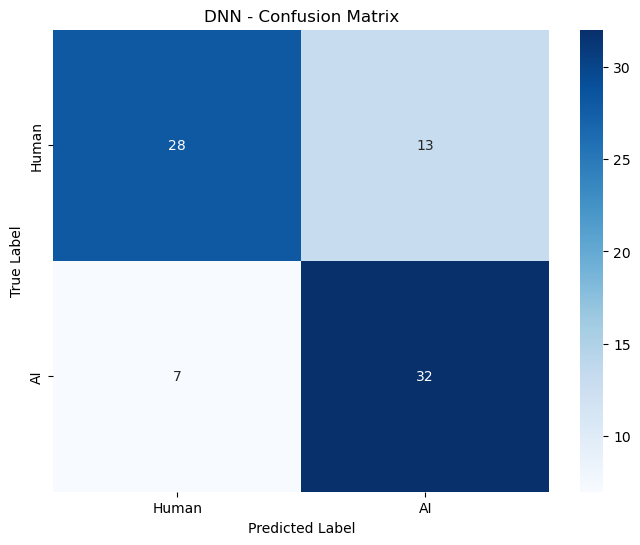


LSTM Classification Report:
              precision    recall  f1-score   support

       Human       0.70      0.98      0.82        41
          AI       0.96      0.56      0.71        39

    accuracy                           0.78        80
   macro avg       0.83      0.77      0.76        80
weighted avg       0.83      0.78      0.76        80



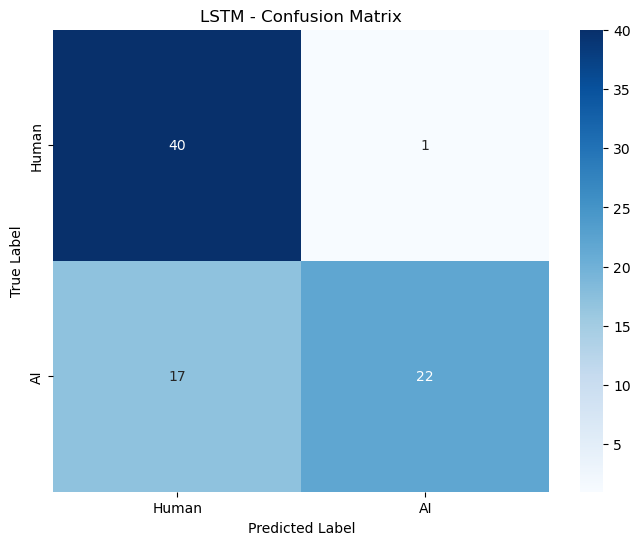

In [9]:
accuracies = {}
for model_name in predictions.keys():
    accuracies[model_name] = accuracy_score(results_df['numeric_label'], results_df[f'{model_name}_pred'])
    print(f"{model_name} accuracy: {accuracies[model_name]:.4f}")

print("\nDetailed Classification Reports:")
for model_name in predictions.keys():
    print(f"\n{model_name.upper()} Classification Report:")
    print(classification_report(
        results_df['numeric_label'], 
        results_df[f'{model_name}_pred'],
        target_names=['Human', 'AI']
    ))
    
    cm = confusion_matrix(results_df['numeric_label'], results_df[f'{model_name}_pred'])
    plt.figure(figsize=(8, 6))
    sns.heatmap(
        cm, 
        annot=True, 
        fmt='d', 
        cmap='Blues',
        xticklabels=['Human', 'AI'],
        yticklabels=['Human', 'AI']
    )
    plt.title(f'{model_name.upper()} - Confusion Matrix')
    plt.ylabel('True Label')
    plt.xlabel('Predicted Label')
    plt.show()


## Visualize Results

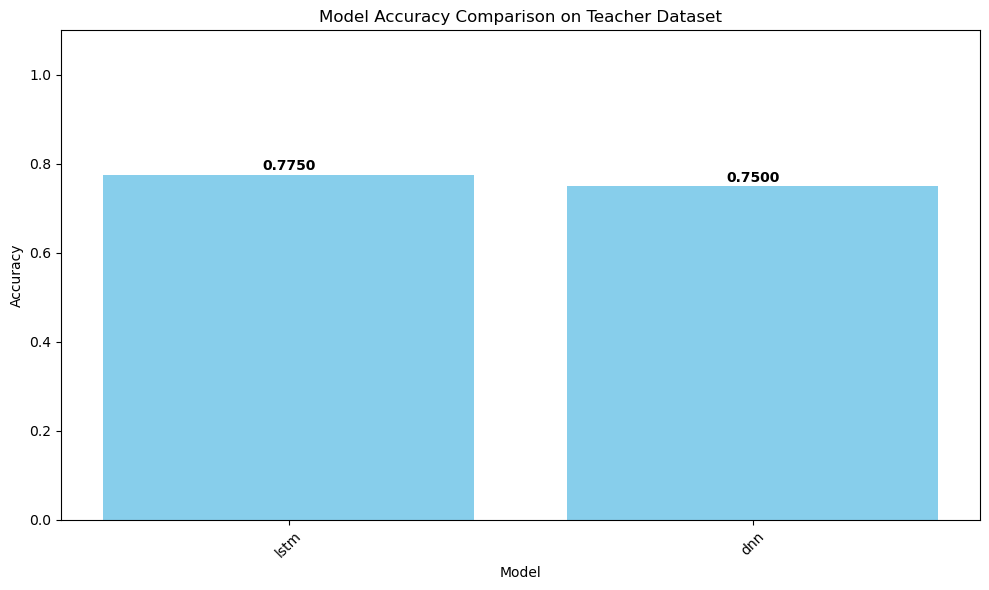


Examining incorrect predictions:

dnn made 20 incorrect predictions:
ID: D1-2
Text: The cell cycle is the process by which a cell grows, duplicates its DNA, and divides into two daught...
True label: AI, Predicted: Human (Probability: 0.0137)
--------------------------------------------------------------------------------
ID: D1-4
Text: A photon is a fundamental particle of light and other electromagnetic radiation. It has no mass, no ...
True label: AI, Predicted: Human (Probability: 0.0167)
--------------------------------------------------------------------------------
ID: D1-7
Text: Thalidomide is a pharmaceutical drug, first prepared in 1957 in Germany, prescribed for treating mor...
True label: Human, Predicted: AI (Probability: 0.9230)
--------------------------------------------------------------------------------
ID: D1-8
Text: Thalidomide is a drug that was first developed in the 1950s as a sedative and later prescribed to pr...
True label: AI, Predicted: Human (Probability:

In [10]:
plt.figure(figsize=(10, 6))
model_names = list(accuracies.keys())
acc_values = list(accuracies.values())

sorted_indices = np.argsort(acc_values)[::-1]
sorted_names = [model_names[i] for i in sorted_indices]
sorted_accs = [acc_values[i] for i in sorted_indices]

bars = plt.bar(sorted_names, sorted_accs, color='skyblue')

for bar, acc in zip(bars, sorted_accs):
    plt.text(
        bar.get_x() + bar.get_width()/2,
        bar.get_height() + 0.01,
        f'{acc:.4f}',
        ha='center',
        fontweight='bold'
    )

plt.title('Model Accuracy Comparison on Teacher Dataset')
plt.xlabel('Model')
plt.ylabel('Accuracy')
plt.ylim(0, 1.1)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

print("\nExamining incorrect predictions:")
for model_name in predictions.keys():
    incorrect = results_df[results_df[f'{model_name}_correct'] == False]
    print(f"\n{model_name} made {len(incorrect)} incorrect predictions:")
    
    if len(incorrect) > 0:
        for _, row in incorrect.iterrows():
            true_label = 'Human' if row['numeric_label'] == 0 else 'AI'
            pred_label = 'Human' if row[f'{model_name}_pred'] == 0 else 'AI'
            print(f"ID: {row['ID']}")
            print(f"Text: {row['Text'][:100]}...")  # Show first 100 chars
            print(f"True label: {true_label}, Predicted: {pred_label} (Probability: {row[f'{model_name}_prob']:.4f})")
            print("-" * 80)


## Conclusion

In [11]:
print("\nModel Performance Summary:")
for model_name, accuracy in sorted(accuracies.items(), key=lambda x: x[1], reverse=True):
    print(f"{model_name}: {accuracy:.4f}")

if accuracies:
    best_model = max(accuracies.items(), key=lambda x: x[1])[0]
    print(f"\nBest performing model: {best_model} with accuracy {accuracies[best_model]:.4f}")
    
    if 'ensemble' in best_model:
        print("The ensemble model outperforms individual models, suggesting that combining models is effective.")
    else:
        print(f"The {best_model} model performs best on this dataset.")
else:
    print("No models were evaluated.")

print("\nRecommendations:")
print("1. For production use, consider using the best performing model.")
print("2. If multiple models have similar performance, consider using an ensemble approach.")
print("3. For challenging samples that all models misclassify, consider collecting more similar training data.")



Model Performance Summary:
lstm: 0.7750
dnn: 0.7500

Best performing model: lstm with accuracy 0.7750
The lstm model performs best on this dataset.

Recommendations:
1. For production use, consider using the best performing model.
2. If multiple models have similar performance, consider using an ensemble approach.
3. For challenging samples that all models misclassify, consider collecting more similar training data.
